In [21]:
%matplotlib notebook

import numpy as np
from matplotlib import pyplot as plt

from mmkin import *
from scipy import optimize

Some notes about the state of the analysis:

1. There seems to be a decrease in V0 / [E] as a function of [E] after ~1-2 uM... why?? Check 
    1. baseline correction, 
    2. potential apparent reduction of velocity due to being too slow with the pipette,
2. The wt_dmso trail is a bit of a mess. Why? Investigate. It seems, though, that the V's are ~2x higher

* work on more robust automatic linear fitting

In [22]:
#mutant = 'wt'
mutant = 'N214A'
#mutant = 'Q256A'
#mutant = 'S284A'
#mutant = 'wt_dmso'

if mutant == 'wt':
    ks = KineticsSeries('./wt/wt.yaml', corrections='./config.yaml', prefix='./wt')
elif mutant == 'N214A':
    ks = KineticsSeries('./N214A/n214a.yaml', corrections='./config.yaml', prefix='./N214A')
elif mutant == 'Q256A':
    ks = KineticsSeries('./Q256A/q256a.yaml', corrections='./config.yaml', prefix='./Q256A')
elif mutant == 'S284A':
    ks = KineticsSeries('./S284A/s284a.yaml', corrections='./config.yaml', prefix='./S284A')
elif mutant == 'wt_dmso':
    ks = KineticsSeries('./wt_dmso/wt_dmso.yaml', corrections='./config.yaml', prefix='./wt_dmso')
else:
    raise NameError()

Loading: 210414_20_2_02_002µM_MproN214A.csv...
 ... excluded
Loading: 210421_20_and_10_µM_MproN214A.csv...
 ... excluded
Loading: 210421_5_and_2_µM_MproN214A.csv...
 ... excluded
Loading: 210427_buffer_160_and_80µM_MproN214A.csv...
Loading: 210427_buffer_160_and_80µM_MproN214A_2.csv...
Loading: 210427_40_20_and_10µM_MproN214A.csv...
Loading: 210427_5_and_2µM_MproN214A.csv...
Loading: 210507_buffer_20µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210507_10µM_MproWT_N_Q_S.csv...
 ... excluded


In [23]:
ps = [2.0, 5.0, 10.0, 20.0, 40.0, 80.0, 160.0]
#ps = [10.0, 20.0, 40.0, 80.0, 160.0]
ss = np.array([320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0])
#ss = np.array([320.0, 160.0, 80.0, 40.0])

n_p = len(ps)
n_s = len(ss)
print(n_p, n_s)

ks.fit_v0(r2_threshold=0.0)

7 7
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero
ds between v0 -1e-2 and 0.0, set to zero


<IPython.core.display.Javascript object>


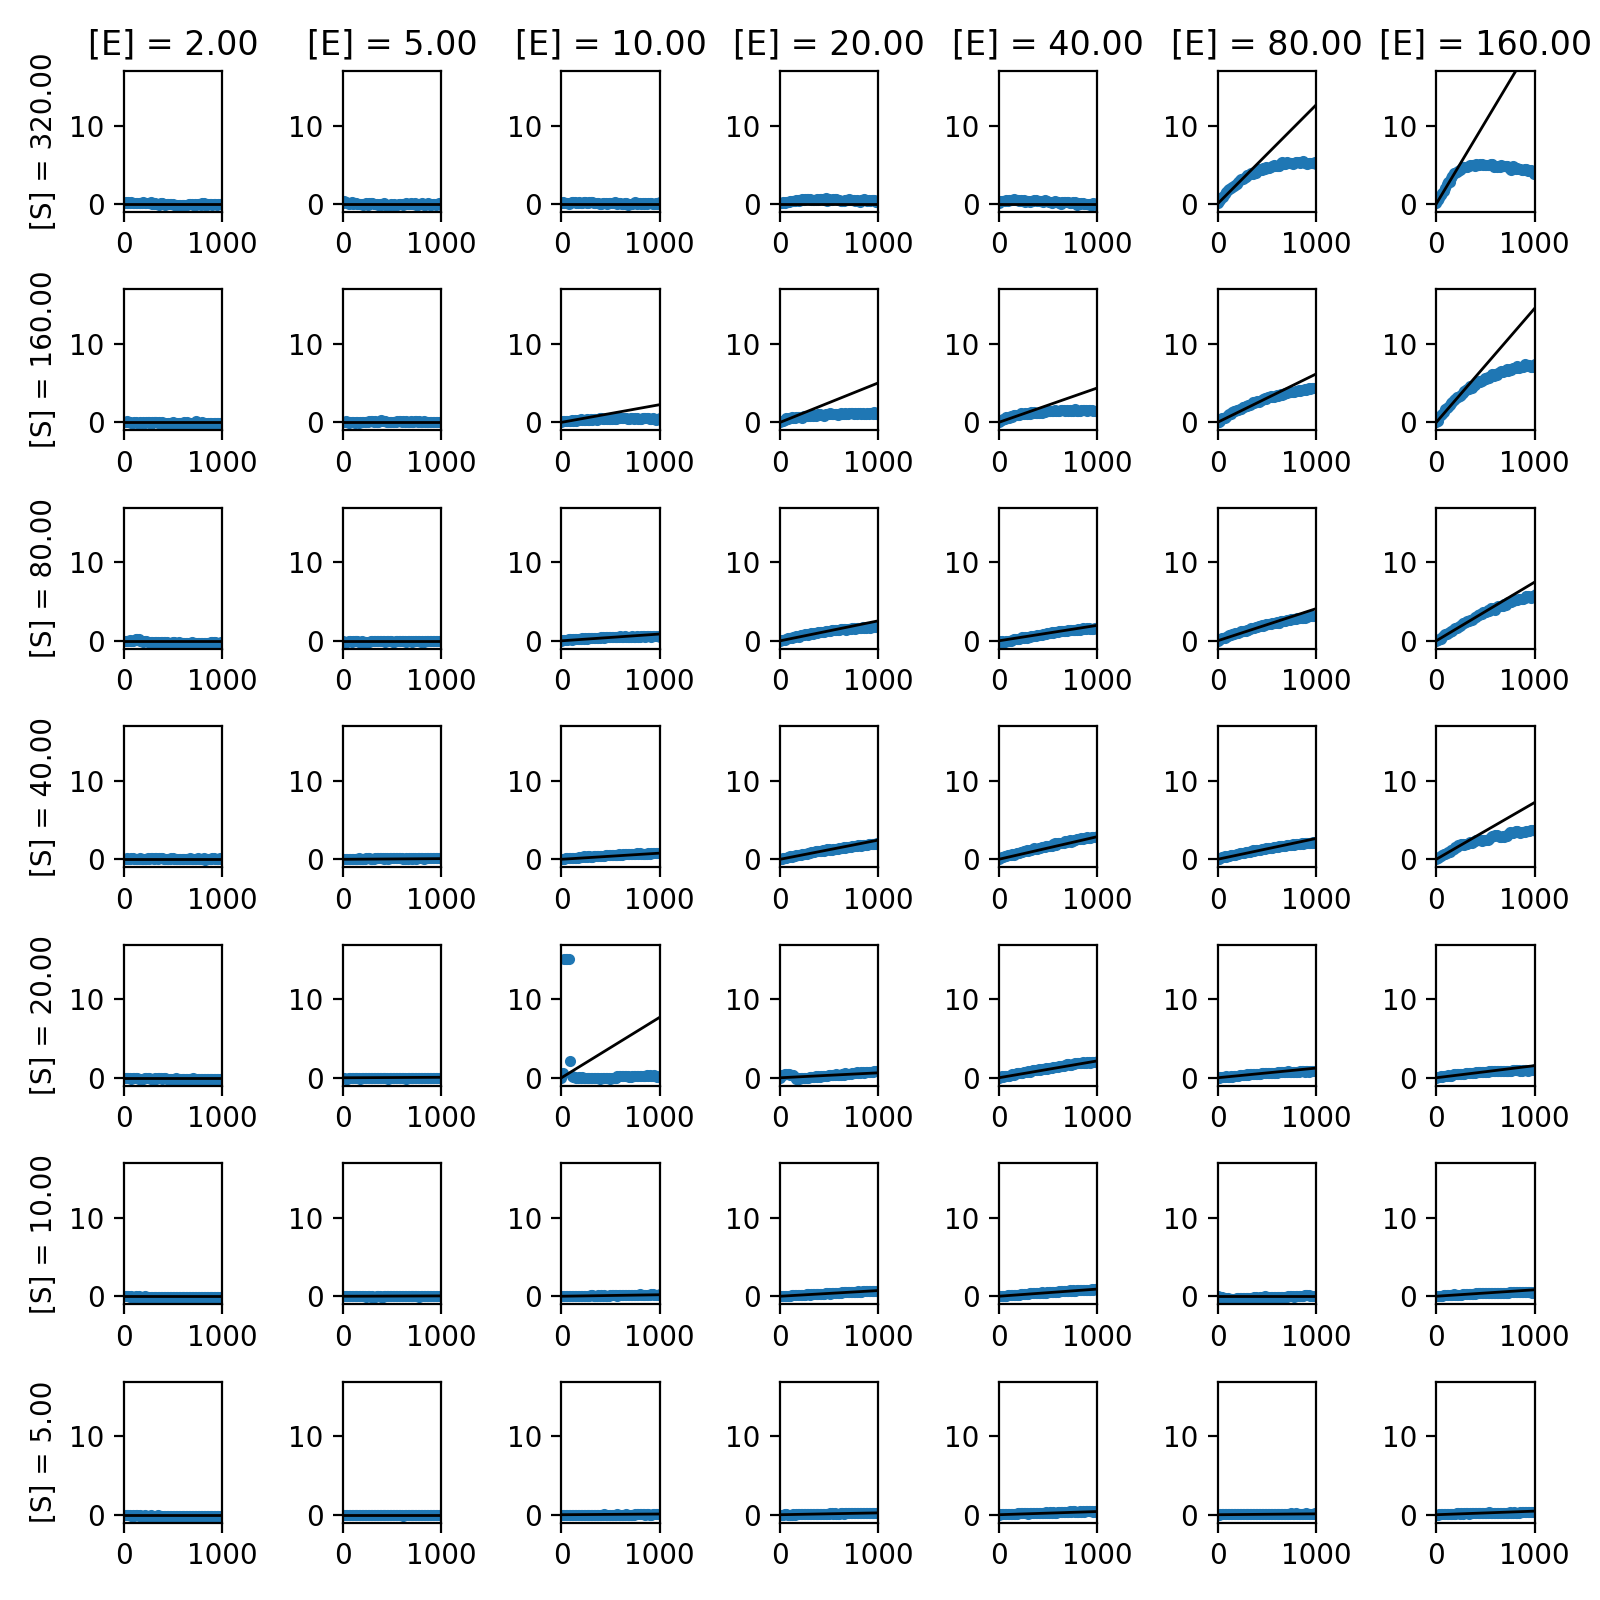

In [24]:
fig, axes = plt.subplots(n_s, n_p, figsize=(8,8))

for i_p,p in enumerate(ps):
    for i_s,s in enumerate(ss):
        
        v0_set = []
        
        for entry in ks.get(p, s):
            
            if i_s == 0:
                axes[i_s, i_p].set_title('[E] = %.2f' % p)
            if i_p == 0:
                axes[i_s, i_p].set_ylabel('[S] = %.2f' % s)
                
            axes[i_s, i_p].set_xlim([0, 1000])
            axes[i_s, i_p].set_ylim([-1, 17])
            
            if entry['exclude']:
                print('excluded: p=%f / s=%f' % (p, s))
                continue
            
            t = entry['dt'] * np.arange(len(entry['timeseries']))
            axes[i_s, i_p].plot(t, entry['timeseries'], '.')
            axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1)
            
plt.tight_layout()
#plt.savefig('figures/%s_traces.pdf' % mutant)
plt.show()

<IPython.core.display.Javascript object>


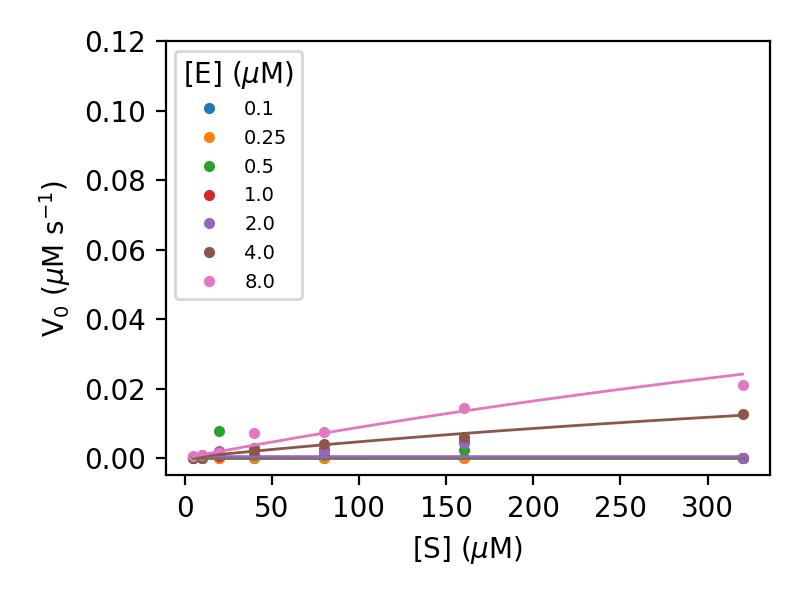

[E]	k_cat		err		K_m		err
---	-----		---		---		---
0.10	8.01e-180	inf	1.00e+00	inf
0.25	1.02e-04	7.44e-06	-2.24e+00	5.81e-01
0.50	3.17e-04	8.50e-06	2.23e+00	2.39e-01
1.00	3.04e-04	6.39e-06	2.23e-01	1.41e-01
2.00	1.75e-04	3.31e-06	-1.72e+00	9.47e-02
4.00	1.18e-02	1.56e-03	9.12e+02	1.33e+02
8.00	1.41e-02	2.46e-03	1.18e+03	2.19e+02


/Users/TJ/opt/miniconda3/lib/python3.8/site-packages/scipy/optimize/minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [25]:
kinetic_params = np.zeros([n_p, 3])

plt.figure(figsize=(4,3))

ax1 = plt.subplot(111)
for p in ps:
    s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)
    ax1.plot(s0s, v0s, '.')
    
ax1.set_ylim([-0.005, 0.12])
    
ax1.set_xlabel('[S] ($\mu$M)')
ax1.set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')

ax1.legend( np.array(ps) / 20.0, title='[E] ($\mu$M)', fontsize=7, loc=2)

# fit
print('[E]\tk_cat\t\terr\t\tK_m\t\terr')
print('---\t-----\t\t---\t\t---\t\t---')

plt.gca().set_prop_cycle(None)
for i,p in enumerate(ps):
    
    s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)
    
    (k_cat, K_m), perr = fit_mm(v0s, s0s, p / 20.0, v0errs=v0errs)

    print('%.2f\t%.2e\t%.2e\t%.2e\t%.2e' % (p/20.0, k_cat, perr[0], K_m, perr[1]))
    kinetic_params[i,:] = np.array([p, k_cat, K_m])
    
    S = np.linspace(ss.min(), ss.max(), 100)
    V_fit = mm( p / 20.0, S, k_cat, K_m)
    ax1.plot(S, V_fit, lw=1)

    
plt.tight_layout()
plt.savefig('figures/%s_mm.pdf' % mutant)
plt.show()

<IPython.core.display.Javascript object>


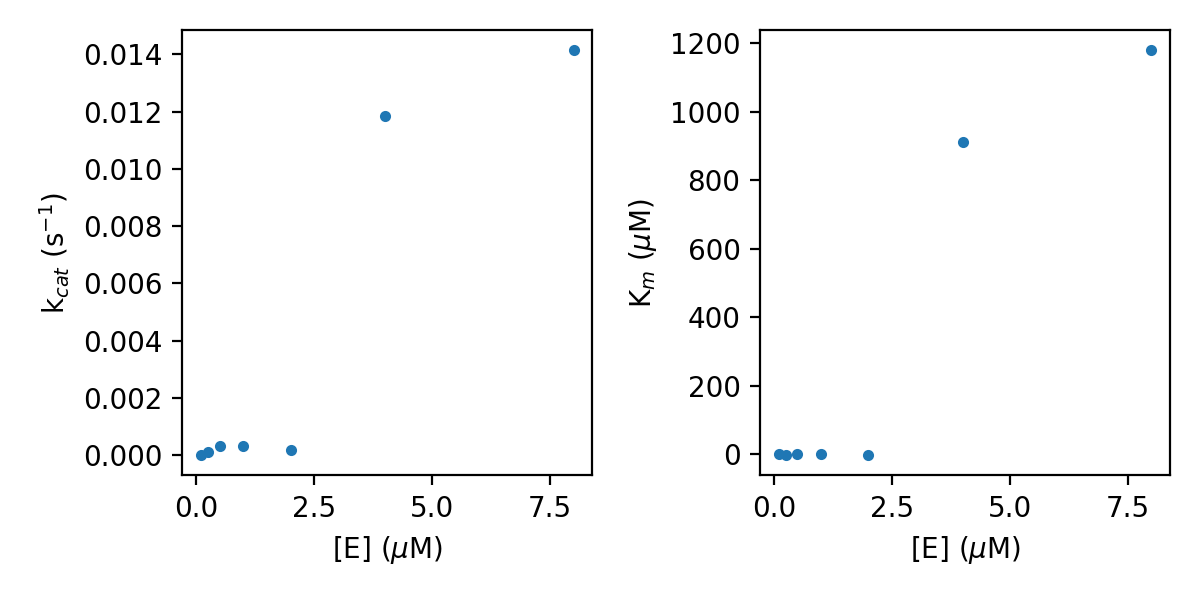

In [26]:
plt.figure(figsize=(6,3))

plt.subplot(121)
plt.plot(kinetic_params[:,0] / 20.0, kinetic_params[:,1], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('k$_{cat}$ (s$^{-1}$)')

plt.subplot(122)
plt.plot(kinetic_params[:,0] / 20.0, kinetic_params[:,2], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('K$_m$ ($\mu$M)')

plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


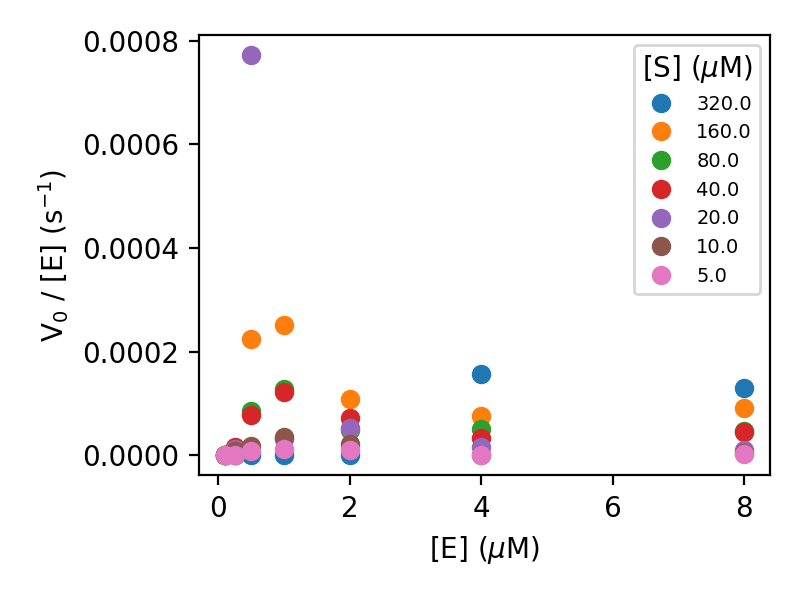

In [27]:
# plot V0 / E

kinetic_params = np.zeros([n_p, 3])

plt.figure(figsize=(4,3))

ax1 = plt.subplot(111)
for s in ss:
    _, p0s, v0s, v0errs = ks.get_set_v0s(ps, [s])
    #ps = np.array(ps)
    ax1.plot( p0s / 20.0, v0s / p0s, 'o')
    
#ax1.set_ylim([-0.005, 0.12])
    
ax1.set_xlabel('[E] ($\mu$M)')
ax1.set_ylabel('V$_0$ / [E] (s$^{-1}$)')

ax1.legend( np.array(ss), title='[S] ($\mu$M)', fontsize=7, loc=1)
    
plt.tight_layout()
plt.savefig('figures/%s_mm.pdf' % mutant)
plt.show()